<a href="https://colab.research.google.com/github/ZanebRA/urdu-ocr-codesaviours-si26-zaneb/blob/main/SI26_Week2_Zaneb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 - Urdu OCR Image Preprocessing

This notebook preprocesses Urdu text-line images by converting them to grayscale, resizing them to a standard size, removing image noise, and applying binary thresholding. The processed images will later be used to evaluate Tesseract OCR and prepare the dataset for model training.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install opencv-python-headless pillow

import cv2
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
def preprocess_image(image_path, save_path):
    # Load image
    img = cv2.imread(image_path)

    if img is None:
        print(f"Could not load: {image_path}")
        return

    # Step 1: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Step 2: Resize image
    resized = cv2.resize(gray, (512, 128))

    # Step 3: Remove noise
    denoised = cv2.fastNlMeansDenoising(resized, h=10)

    # Step 4: Convert to black and white
    _, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

    # Save processed image
    cv2.imwrite(save_path, binary)

    return binary

# Create output folder
os.makedirs("data/processed", exist_ok=True)

print("Preprocessing function ready!")

Preprocessing function ready!


In [6]:
import glob
# Path to your raw images in Google Drive
raw_folder = "/content/drive/MyDrive/data/data/raw"

# Find all JPG and PNG images in all subfolders
all_images = glob.glob(raw_folder + "/**/*.jpg", recursive=True)
all_images += glob.glob(raw_folder + "/**/*.png", recursive=True)

print(f"Found {len(all_images)} images to process")

processed_count = 0

for img_path in all_images:
    filename = os.path.basename(img_path)
    save_path = f"data/processed/{filename}"

    result = preprocess_image(img_path, save_path)

    if result is not None:
        processed_count += 1

print(f"Done! Processed {processed_count} images")
print("Check data/processed/ folder")

Found 100 images to process
Done! Processed 100 images
Check data/processed/ folder


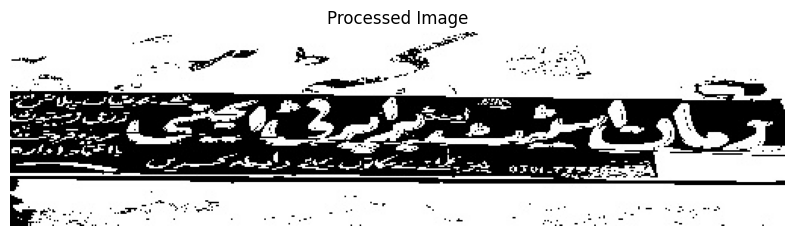

In [8]:
import matplotlib.pyplot as plt

# Display one processed image
sample_image = "data/processed/14.jpg"   # Change the filename if needed

img = cv2.imread(sample_image, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,3))
plt.imshow(img, cmap="gray")
plt.title("Processed Image")
plt.axis("off")
plt.show()

In [9]:
# Install Tesseract OCR and Python wrapper
!apt-get update
!apt-get install -y tesseract-ocr
!pip install pytesseract

import pytesseract
import cv2
import matplotlib.pyplot as plt

print("Tesseract installed successfully!")

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,416 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,613 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,6

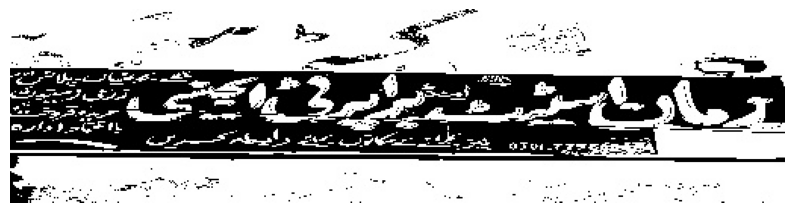

OCR Output:
 



In [10]:
# Load a processed image
image_path = "data/processed/14.jpg"   # Change the filename if needed

img = cv2.imread(image_path)

# Display the image
plt.figure(figsize=(10,3))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Run OCR
text = pytesseract.image_to_string(img)

print("OCR Output:")
print(text)

In [11]:
# Install Urdu language data for Tesseract
!apt-get install -y tesseract-ocr-urd

# Run OCR using Urdu language
text = pytesseract.image_to_string(img, lang="urd")

print("OCR Output (Urdu):")
print(text)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-urd
0 upgraded, 1 newly installed, 0 to remove and 87 not upgraded.
Need to get 1,000 kB of archives.
After this operation, 1,413 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-urd all 1:4.00~git30-7274cfa-1.1 [1,000 kB]
Fetched 1,000 kB in 0s (5,530 kB/s)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
OCR Output (Urdu):
 



In [12]:
import os
# List of sample processed images
test_images = [
    "data/processed/14.jpg",                  # Signboard
    "data/processed/Screenshot (1257).png",   # Book
    "data/processed/Screenshot (1246).png",   # Newspaper
    "data/processed/001_001_7.png",           # Other
    "data/processed/urdu_1.png"               # Synthetic
]
for image_path in test_images:
    print("=" * 60)
    print("Testing:", os.path.basename(image_path))

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found!\n")
        continue

    text = pytesseract.image_to_string(img, lang="urd")
    print("OCR Output:")
    print(text if text.strip() else "[No text detected]")
    print()

Testing: 14.jpg
OCR Output:
[No text detected]

Testing: Screenshot (1257).png
OCR Output:
مہب لا کااہی شر سے دم نتم


Testing: Screenshot (1246).png
OCR Output:
پاکستان اور سمونی غرب کے درمیاز سکیوٹی کے شدبے میں دفارمن
پاادائت پر استخظ


Testing: 001_001_7.png
OCR Output:
[No text detected]

Testing: urdu_1.png
OCR Output:
خقتقتقتتا متاح




In [13]:
import os
print(os.listdir("data"))

['processed']


In [14]:
!zip -r processed.zip data/processed

  adding: data/processed/ (stored 0%)
  adding: data/processed/001_006_6.png (deflated 12%)
  adding: data/processed/Screenshot (1255).png (deflated 11%)
  adding: data/processed/Screenshot (1246).png (deflated 18%)
  adding: data/processed/Screenshot (1251).png (deflated 22%)
  adding: data/processed/001_002_1.png (deflated 17%)
  adding: data/processed/urdu_11.png (deflated 48%)
  adding: data/processed/urdu_2.png (deflated 48%)
  adding: data/processed/Screenshot (1253).png (deflated 13%)
  adding: data/processed/urdu_3.png (deflated 50%)
  adding: data/processed/001_005_6.png (deflated 18%)
  adding: data/processed/001_005_4.png (deflated 12%)
  adding: data/processed/001_002_2.png (deflated 20%)
  adding: data/processed/001_002_5.png (deflated 18%)
  adding: data/processed/urdu_16.png (deflated 51%)
  adding: data/processed/001_005_1.png (deflated 21%)
  adding: data/processed/19.jpg (deflated 13%)
  adding: data/processed/002_001_2.png (deflated 67%)
  adding: data/processed/urdu